<a href="https://colab.research.google.com/github/ryueuitae-blip/AIEYES-STUDY/blob/euitae-branch/%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_%EB%B0%8F_%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns


In [47]:
sns.set_style('whitegrid')
# 흰색 배경에 회색 격자선

In [48]:
titanic = sns.load_dataset('titanic')

In [49]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [50]:
titanic.describe()
# 데이터 분포 확인

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [51]:
titanic.dropna().describe()
# 결측치 제거

,survived,pclass,age,sibsp,parch,fare
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,0.675824,1.192308,35.623187,0.467033,0.478022,78.919735
std,0.469357,0.516411,15.671615,0.645007,0.755869,76.490774
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,47.750000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


In [52]:
titanic.var(numeric_only=True)
#데이터프레임의 숫자형 컬럼들에 대한 분산(variance)

,0
survived,0.236772
pclass,0.699015
age,211.019125
sibsp,1.216043
parch,0.649728
fare,2469.436846
adult_male,0.239723
alone,0.239723


In [53]:
titanic.select_dtypes(include=np.number).apply(lambda x: (x - x.mean()).abs().mean())
# mad:평균절대편차 pandas 2.0.0 버전부터 제거

,0
survived,0.473013
pclass,0.761968
age,11.322944
sibsp,0.713780
parch,0.580742
fare,28.163692


In [54]:
titanic.groupby('class').count()
# class 별로 구분해줘

/tmp/ipykernel_4543/3018353286.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class').count()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,216,216,216,186,216,216,216,214,216,216,175,214,216,216
Second,184,184,184,173,184,184,184,184,184,184,16,184,184,184
Third,491,491,491,355,491,491,491,491,491,491,12,491,491,491


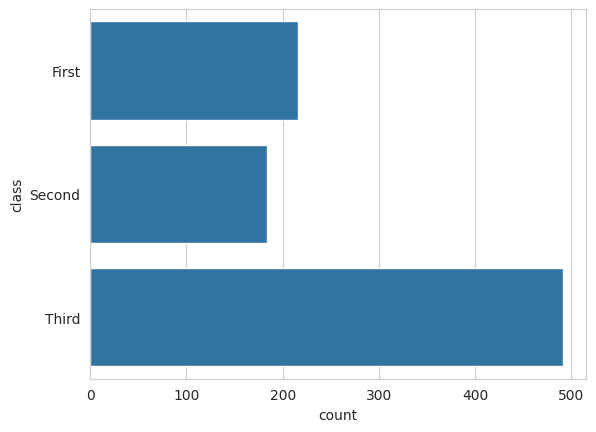

In [55]:
sns.countplot(y='class',data= titanic);
# countplot 함수 사용 막대그래프
# y='class'는 'class' 컬럼의 각 카테고리를 y축 표시

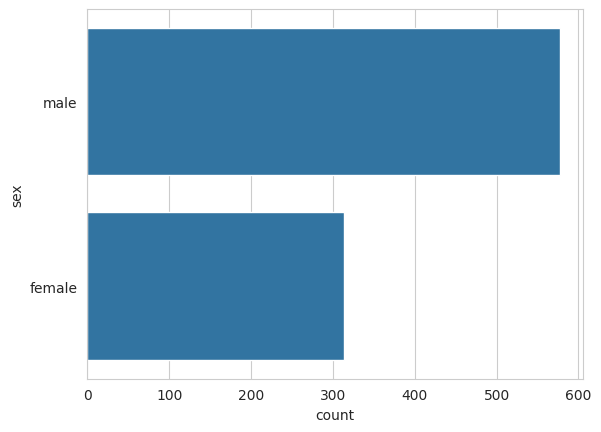

In [56]:
sns.countplot(y='sex',data=titanic);

<Axes: xlabel='count', ylabel='alive'>

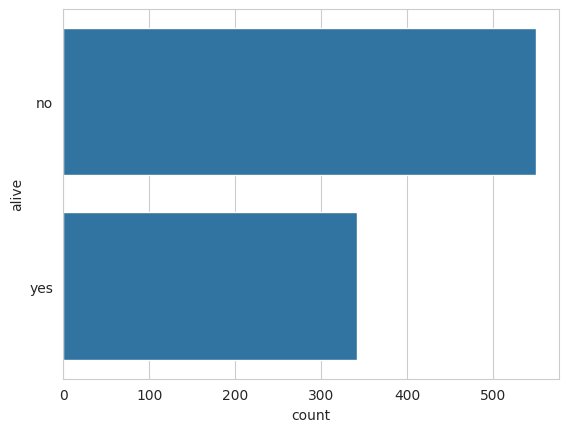

In [57]:
sns.countplot(y='alive',data=titanic)

<Axes: xlabel='count', ylabel='alone'>

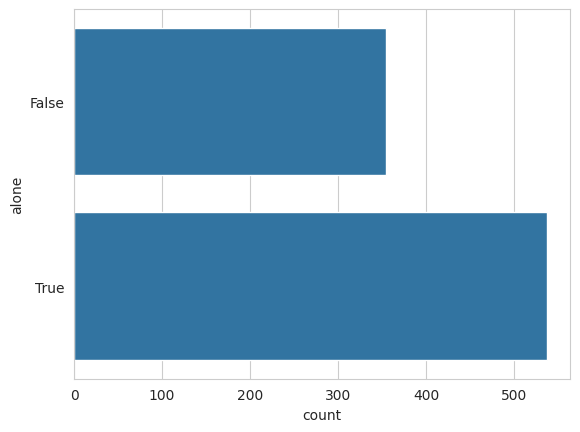

In [58]:
sns.countplot(y='alone',data=titanic)

In [59]:
titanic.groupby('class').std(numeric_only=True)
# class 컬럼을 기준으로 그룹화
# 표준 편차(standard deviation)

/tmp/ipykernel_4543/2054543162.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class').std(numeric_only=True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
class,,,,,,,,
First,0.484026,0.0,14.802856,0.611898,0.693997,78.380373,0.498555,0.501140
Second,0.500623,0.0,14.001077,0.601633,0.690963,13.417399,0.499911,0.497081
Third,0.428949,0.0,12.495398,1.374883,0.888861,11.778142,0.477552,0.474233


In [60]:
titanic.groupby('class')['fare'].median()
# class열로 기준 그룹화
# fare열에 대한 중앙값 계산

/tmp/ipykernel_4543/2106923377.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')['fare'].median()


,fare
class,
First,60.2875
Second,14.2500
Third,8.0500


In [61]:
titanic.query("alive == 'yes'")
# 생존한 사람

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [62]:
titanic.query("alive == 'yes'").groupby('class').count()
# class 기준으로 분류

/tmp/ipykernel_4543/309516766.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query("alive == 'yes'").groupby('class').count()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,136,136,136,122,136,136,136,134,136,136,117,134,136,136
Second,87,87,87,83,87,87,87,87,87,87,13,87,87,87
Third,119,119,119,85,119,119,119,119,119,119,6,119,119,119


In [64]:
titanic.groupby('class')['age'].describe()
# 클래스 별로 묶어
# 나이만 볼게
# 요약- class 와 age의 상관관계 확인

/tmp/ipykernel_4543/699673226.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')['age'].describe()


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
First,186.0,38.233441,14.802856,0.92,27.0,37.0,49.0,80.0
Second,173.0,29.877630,14.001077,0.67,23.0,29.0,36.0,70.0
Third,355.0,25.140620,12.495398,0.42,18.0,24.0,32.0,74.0


In [66]:
titanic.query("alive == 'yes'").groupby('class').describe()
#

/tmp/ipykernel_4543/2138602979.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query("alive == 'yes'").groupby('class').describe()


survived                                    pclass       ... parch  \
          count mean  std  min  25%  50%  75%  max  count mean  ...   75%   
class                                                           ...         
First     136.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  136.0  1.0  ...   1.0   
Second     87.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0   87.0  2.0  ...   1.0   
Third     119.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  119.0  3.0  ...   1.0   

              fare                                                    \
        max  count       mean        std      min       25%      50%   
class                                                                  
First   2.0  136.0  95.608029  85.286820  25.9292  50.98545  77.9583   
Second  3.0   87.0  22.055700  10.853502  10.5000  13.00000  21.0000   
Third   5.0  119.0  13.694887  10.692993   0.0000   7.77500   8.5167   

                              
               75%       max  
class                         
First   111.481225  512.3292  
Second   26.250000   65.0000  
Third    15.875000   56.4958  

[3 rows x 48 columns]

In [69]:
titanic.groupby('sex')['age'].aggregate([min, np.median, max])
#성별을 기준 나이 칼럼 최값 중앙값 최대값

/tmp/ipykernel_4543/1356425346.py:1: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  titanic.groupby('sex')['age'].aggregate([min, np.median, max])
/tmp/ipykernel_4543/1356425346.py:1: FutureWarning: The provided callable <function median at 0x7f8b2ec75940> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  titanic.groupby('sex')['age'].aggregate([min, np.median, max])
/tmp/ipykernel_4543/1356425346.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  titanic.groupby('sex')['age'].aggregate([min, 

,min,median,max
sex,,,
female,0.75,27.0,63.0
male,0.42,29.0,80.0


In [74]:
titanic.query("age > 30 ").groupby('class').median(numeric_only=True)
# 30 초과 age 그룹의 중간값

/tmp/ipykernel_4543/316042734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query("age > 30 ").groupby('class').median(numeric_only=True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
class,,,,,,,,
First,1.0,1.0,45.0,0.0,0.0,56.9292,1.0,0.0
Second,0.0,2.0,39.0,0.0,0.0,14.0000,1.0,1.0
Third,0.0,3.0,38.0,0.0,0.0,8.0500,1.0,1.0


In [76]:
titanic.query("fare < 20").groupby('class').median(numeric_only=True)

/tmp/ipykernel_4543/229391321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.query("fare < 20").groupby('class').median(numeric_only=True)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
class,,,,,,,,
First,0.0,1.0,38.5,0.0,0.0,0.0000,1.0,1.0
Second,0.0,2.0,30.0,0.0,0.0,13.0000,1.0,1.0
Third,0.0,3.0,25.0,0.0,0.0,7.8958,1.0,1.0


In [81]:
titanic.groupby(['class', 'sex' ])['age'].mean().unstack()

/tmp/ipykernel_4543/1303606189.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['class', 'sex' ])['age'].mean().unstack()


sex,female,male
class,,
First,34.611765,41.281386
Second,28.722973,30.740707
Third,21.750000,26.507589


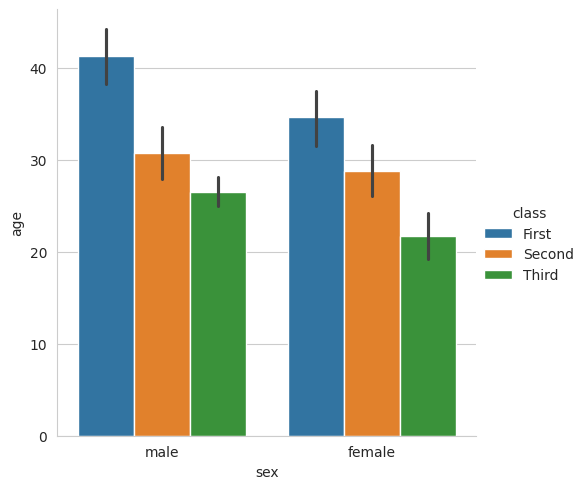

In [84]:
sns.catplot(x='sex', y='age', hue='class', kind='bar', data=titanic)
# x축 sex y축 age
# hue:색깔 class 별로 색깔 다르게
# 종류 막대그래프

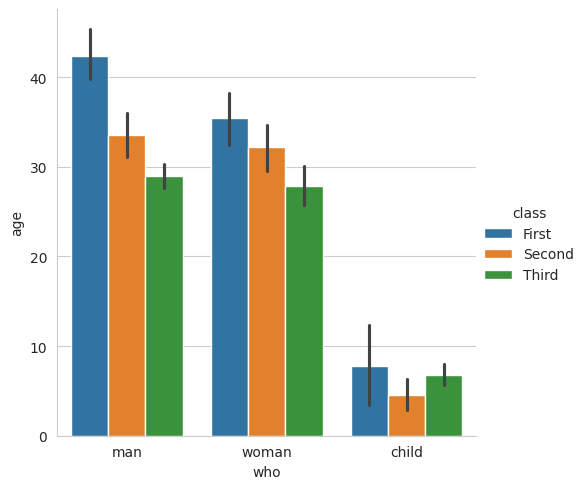

In [86]:
sns.catplot(x='who', y= 'age', hue='class', kind= 'bar', data=titanic)

In [90]:
titanic.groupby(['class','who'])['fare'].mean().unstack()

/tmp/ipykernel_4543/3405321881.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['class','who'])['fare'].mean().unstack()


who,child,man,woman
class,,,
First,139.382633,65.951086,104.317995
Second,28.323905,19.054124,20.868624
Third,23.220190,11.340213,15.354351


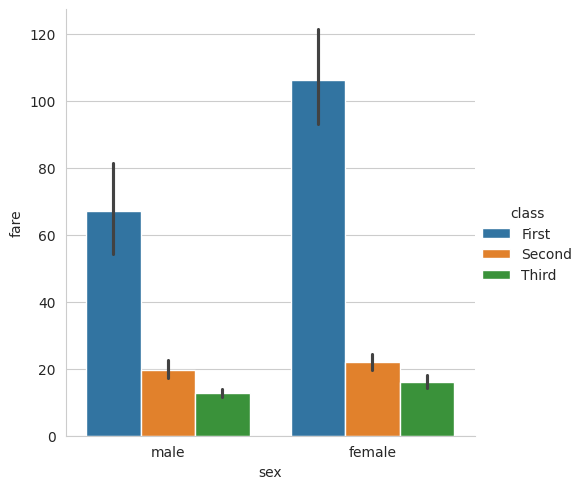

In [95]:
sns.catplot(x='sex', y='fare', hue='class', kind='bar', data=titanic)

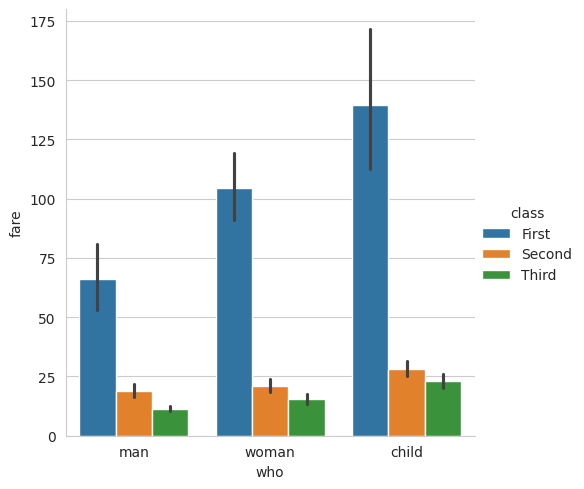

In [97]:
sns.catplot(x='who', y='fare', hue='class', kind='bar', data=titanic)
#

In [99]:
titanic.groupby(['class','sex'])['survived'].mean().unstack()
#여자가 많이 생존함

/tmp/ipykernel_4543/566924644.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['class','sex'])['survived'].mean().unstack()


sex,female,male
class,,
First,0.968085,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


In [100]:
titanic.pivot_table('survived', index='class', columns='who')
# 3등급 생존자 적음

/tmp/ipykernel_4543/1157413278.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='class', columns='who')


who,child,man,woman
class,,,
First,0.833333,0.352941,0.978022
Second,1.000000,0.080808,0.909091
Third,0.431034,0.119122,0.491228


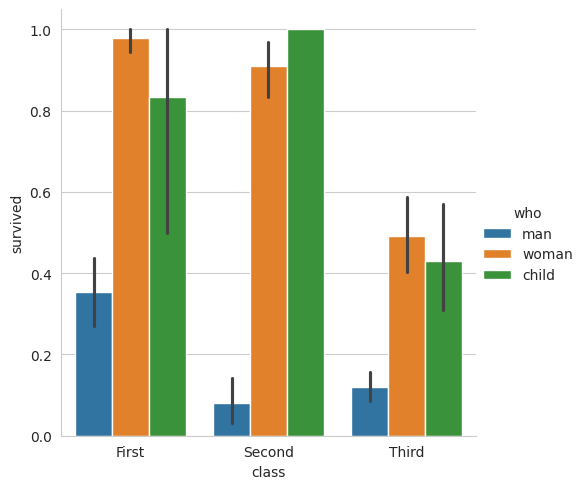

In [103]:
sns.catplot(x='class', y='survived', hue='who', kind='bar', data=titanic)
#성별에 따른  # 아이 포함

In [106]:
age = pd.cut(titanic['age'], bins=[0, 18, 40, 80])
titanic.pivot_table('survived', ['who', age], 'class')

/tmp/ipykernel_4543/2180760308.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['who', age], 'class')


class              First    Second     Third
who   age                                   
child (0, 18]   0.833333  1.000000  0.431034
man   (0, 18]   0.500000  0.000000  0.086957
      (18, 40]  0.478261  0.063492  0.146199
      (40, 80]  0.280000  0.095238  0.064516
woman (0, 18]   1.000000  1.000000  0.461538
      (18, 40]  0.979167  0.914894  0.480000
      (40, 80]  0.961538  0.846154  0.111111

In [107]:
fare = pd.qcut(titanic['fare'], 3)
titanic.pivot_table('survived',['who',age],[fare,'class'])
# 요금 열을 3등분
# 생존율을 기준으로 행 who age 열 fare class

/tmp/ipykernel_4543/2735214516.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived',['who',age],[fare,'class'])


fare           (-0.001, 8.662]           (8.662, 26.0]                      \
class                    First     Third         First    Second     Third   
who   age                                                                    
child (0, 18]              NaN  0.666667           NaN  1.000000  0.703704   
man   (0, 18]              NaN  0.125000           NaN  0.000000  0.000000   
      (18, 40]             0.0  0.138462           NaN  0.078431  0.114286   
      (40, 80]             NaN  0.074074           0.0  0.111111  0.000000   
woman (0, 18]              NaN  0.666667           NaN  1.000000  0.333333   
      (18, 40]             NaN  0.550000           NaN  0.894737  0.461538   
      (40, 80]             NaN  0.000000           1.0  0.818182  0.250000   

fare           (26.0, 512.329]               
class                    First Second Third  
who   age                                    
child (0, 18]         0.833333    1.0  0.08  
man   (0, 18]         0.500000    0.0  0.00  
      (18, 40]        0.523810    0.0  0.50  
      (40, 80]        0.291667    0.0   NaN  
woman (0, 18]         1.000000    NaN  0.00  
      (18, 40]        0.979167    1.0  0.25  
      (40, 80]        0.958333    1.0  0.00

In [111]:
titanic.pivot_table ('survived', index='who', columns='class', margins = True)

/tmp/ipykernel_4543/2627054396.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table ('survived', index='who', columns='class', margins = True)


class,First,Second,Third,All
who,,,,
child,0.833333,1.000000,0.431034,0.590361
man,0.352941,0.080808,0.119122,0.163873
woman,0.978022,0.909091,0.491228,0.756458
All,0.629630,0.472826,0.242363,0.383838


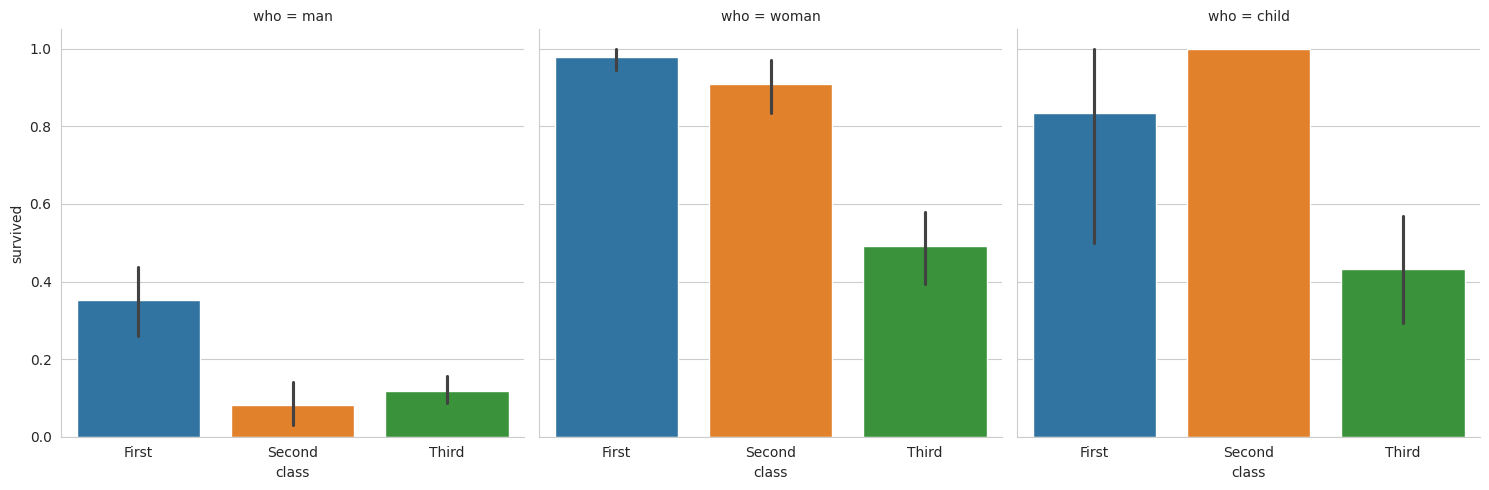

In [115]:
sns.catplot(x='class', y='survived', col='who', kind='bar', hue='class', data=titanic);

In [117]:
titanic.pivot_table('survived', index='deck', columns='class', margins = True)
#생존율 평균, deck()=행, columns= 열, margins=True 전체평균 추가

/tmp/ipykernel_4543/509371857.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='deck', columns='class', margins = True)


class,First,Second,Third,All
deck,,,,
A,0.466667,NaN,NaN,0.466667
B,0.744681,NaN,NaN,0.744681
C,0.593220,NaN,NaN,0.593220
D,0.758621,0.7500,NaN,0.757576
E,0.720000,0.7500,1.0,0.750000
F,NaN,0.8750,0.2,0.615385
G,NaN,NaN,0.5,0.500000
All,0.668571,0.8125,0.5,0.669951


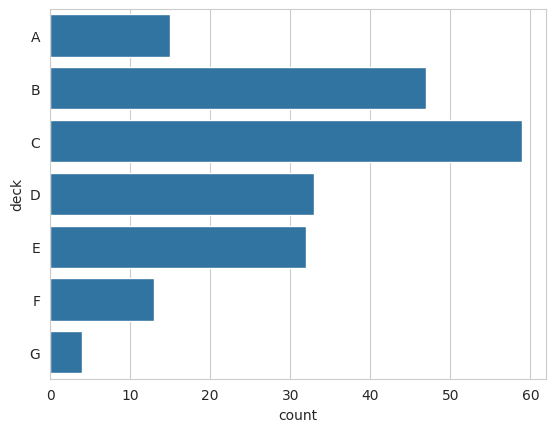

In [119]:
sns.countplot(y='deck', data=titanic);
# y 축에 deck 컬럼에 속하는 데이터 개 막대그래프로

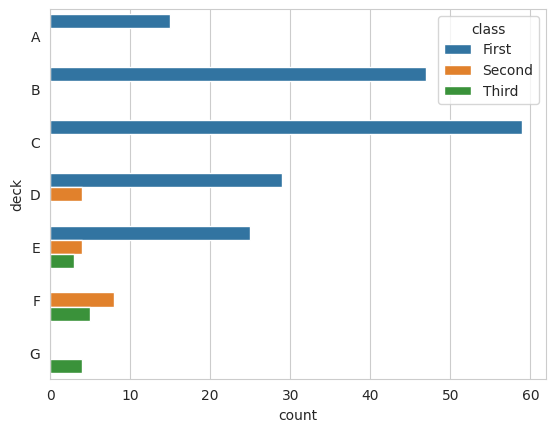

In [121]:
sns.countplot(y='deck', hue='class', data=titanic);
#class 별로 색깔을 넣어줘

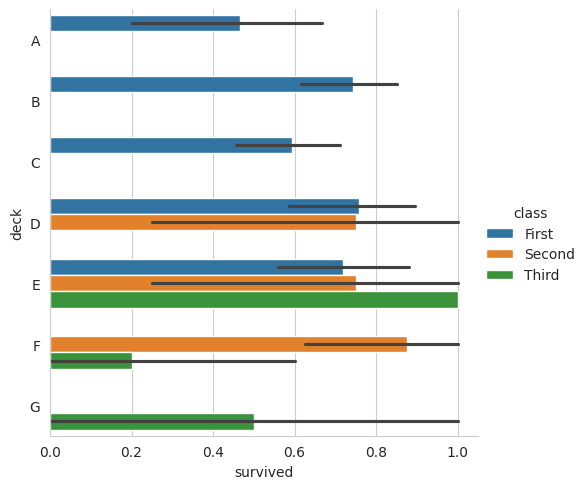

In [123]:
sns.catplot(x='survived', y= 'deck', hue='class', kind='bar', data=titanic);
# 검은색 선: 오차범위 신뢰 구간  선의 길이: 데이터의 신뢰도
# 선의 위치: 실제 생존율이 존재할 것으로 예상되는

In [126]:
titanic.pivot_table('survived', index='embark_town', columns= 'class',margins=True)

/tmp/ipykernel_4543/147929444.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='embark_town', columns= 'class',margins=True)


class,First,Second,Third,All
embark_town,,,,
Cherbourg,0.694118,0.529412,0.378788,0.553571
Queenstown,0.500000,0.666667,0.375000,0.389610
Southampton,0.582677,0.463415,0.189802,0.336957
All,0.626168,0.472826,0.242363,0.382452


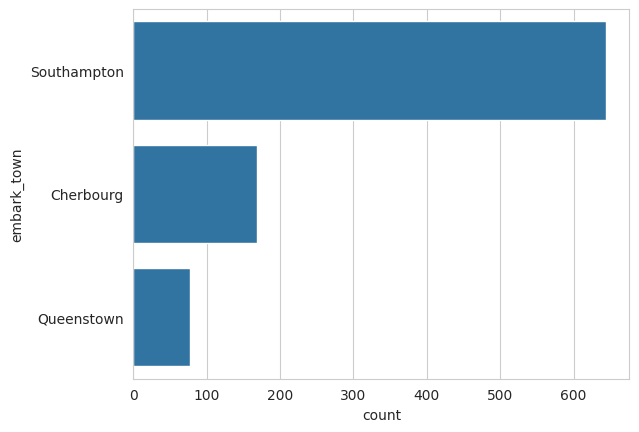

In [127]:
sns.countplot(y='embark_town', data=titanic);
#어디서 탔냐

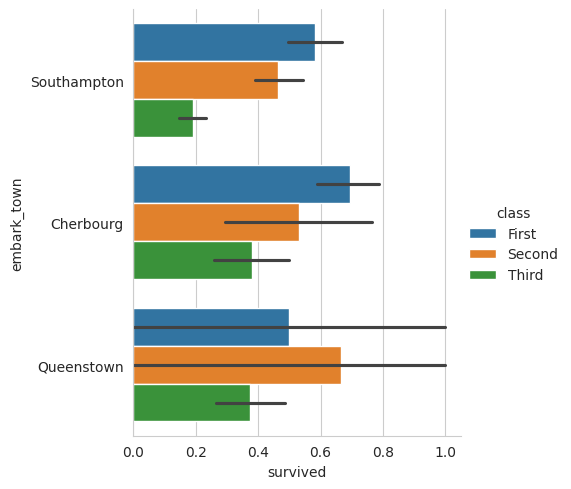

In [128]:
sns.catplot(x='survived', y='embark_town', hue='class', kind='bar', data=titanic);
#Southampton (사우샘프턴): 영국의 출발 항구입니다. 가장 많은 승객(주로 노동자나 3등석 승객)이 여기서 탔습니다.
#Cherbourg (셰르부르): 프랑스의 기항지입니다. 이곳에서 1등석 부자 승객들이 많이 탔다고 알려져 있습니다.
#Queenstown (퀸즈타운): 아일랜드의 기항지입니다. 주로 미국으로 이민 가려는 3등석 승객들이 탔습니다.
# 셰르 부르 사람들의 생존율이 소튼보다 생존율이 높음

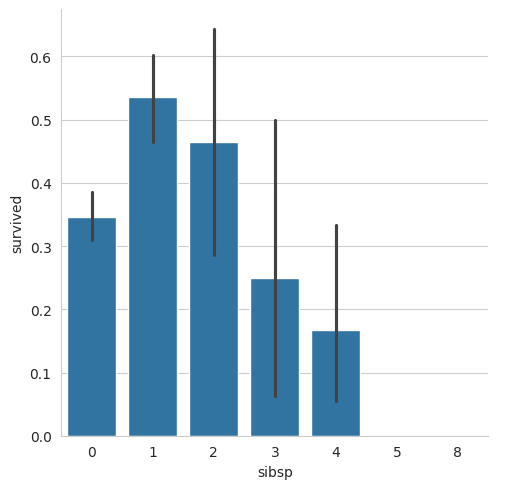

In [130]:
sns.catplot(x='sibsp', y='survived', kind='bar', data=titanic);
# siblings: 형제,자매 spouse: 남편,아내

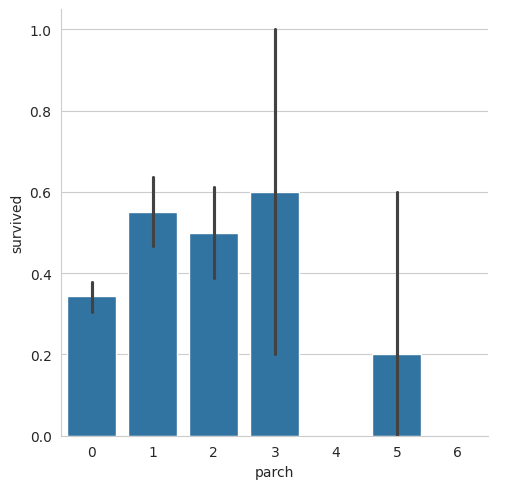

In [132]:
sns.catplot(x='parch', y='survived', kind='bar', data=titanic);
# parents: 부모 children: 자식

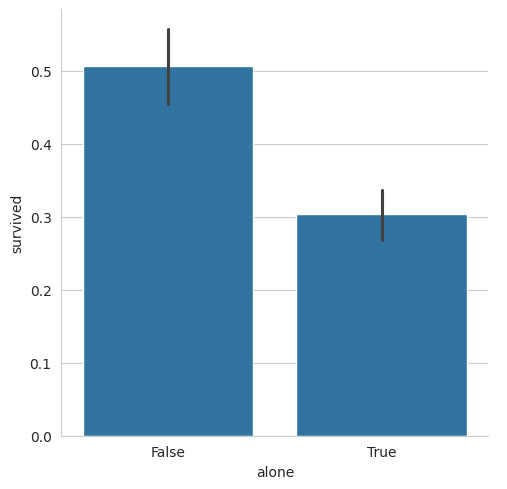

In [133]:
sns.catplot(x='alone', y='survived', kind='bar', data=titanic);
# 동반자가 있을때 생존확률이 높다